In [4]:
from transformers import CLIPModel, CLIPProcessor

model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

config.json: 0.00B [00:00, ?B/s]

c:\Users\raian\source\repos\AI\.env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\raian\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [70]:
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from PIL import Image
import os
import json

class ImageDataset(Dataset):
    def __init__(self, folder):
        super().__init__()
        self.img_paths = []
        self.options = []
        self.labels = []
        for sub_folder in os.listdir('dataset_img_keywords/' + folder):
            self.img_paths.append(os.path.join('dataset_img_keywords/', folder, sub_folder, 'image.png'))
            json_path = os.path.join('dataset_img_keywords/', folder, sub_folder, 'metadata.json')
            with open(json_path, 'r') as file:
                obj = json.load(file)
                self.options.append(obj['word_choices'])
                self.labels.append(obj['correct_words'])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx])
        img = img.resize((224,224))
        return (img, self.options[idx], self.labels[idx])
    
temp_ds = ImageDataset('train')
ds_train, ds_val = train_test_split(temp_ds, test_size=0.1)
len(ds_train), len(ds_val)

(180, 20)

In [71]:
img, options, labels = ds_train[0]
inputs = processor(images=img, text=options, return_tensors='pt', padding=True, truncation=True)
outputs = model(**inputs)

In [72]:
outputs.keys()

odict_keys(['logits_per_image', 'logits_per_text', 'text_embeds', 'image_embeds', 'text_model_output', 'vision_model_output'])

In [73]:
outputs['logits_per_image'].squeeze(0)

tensor([20.5687, 19.3905, 18.6091, 17.0327, 21.0505, 25.0771, 21.5680, 18.1604,
        18.9485, 17.8598, 19.0326, 20.1744, 18.9060, 16.2715, 20.0936, 15.7878,
        18.7334, 19.9473, 18.5640, 25.3650], grad_fn=<SqueezeBackward1>)

In [74]:
import torch
indexes = outputs['logits_per_image'].squeeze(0).argsort(descending = True)[:5]
selection = [options[i] for i in indexes]
selection, labels

(['duck', 'Peas', 'Ficus', 'box', 'ritualtools'],
 ['Peas', 'lightning', 'duck'])

In [75]:
[(text, logit) for text, logit, in zip(options, outputs['logits_per_image'].squeeze(0))]

[('ritualtools', tensor(20.5687, grad_fn=<UnbindBackward0>)),
 ('blessing', tensor(19.3905, grad_fn=<UnbindBackward0>)),
 ('rat', tensor(18.6091, grad_fn=<UnbindBackward0>)),
 ('turkeyvulture', tensor(17.0327, grad_fn=<UnbindBackward0>)),
 ('box', tensor(21.0505, grad_fn=<UnbindBackward0>)),
 ('Peas', tensor(25.0771, grad_fn=<UnbindBackward0>)),
 ('Ficus', tensor(21.5680, grad_fn=<UnbindBackward0>)),
 ('lantern', tensor(18.1604, grad_fn=<UnbindBackward0>)),
 ('crystals', tensor(18.9485, grad_fn=<UnbindBackward0>)),
 ('drill', tensor(17.8598, grad_fn=<UnbindBackward0>)),
 ('Poppy', tensor(19.0326, grad_fn=<UnbindBackward0>)),
 ('sofa', tensor(20.1744, grad_fn=<UnbindBackward0>)),
 ('chair', tensor(18.9060, grad_fn=<UnbindBackward0>)),
 ('catfish', tensor(16.2715, grad_fn=<UnbindBackward0>)),
 ('dog', tensor(20.0936, grad_fn=<UnbindBackward0>)),
 ('coyote', tensor(15.7878, grad_fn=<UnbindBackward0>)),
 ('monitor', tensor(18.7334, grad_fn=<UnbindBackward0>)),
 ('watercolor', tensor(19.947

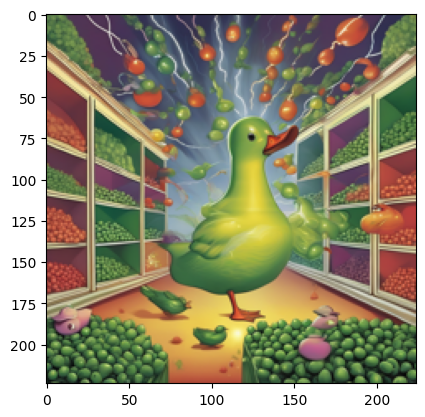

In [76]:
import matplotlib.pyplot as plt
import numpy as np
plt.imshow(np.array(img))

In [83]:
from tqdm import tqdm

def evaluate(model, dataset, processor):
    score_sum = 0
    all_scores = []
    for (img, options, labels) in tqdm(dataset):
        label_indexes = [options.index(label) for label in labels]

        #prompting
        # options = ['an image containing a ' + option for option in options]

        inputs = processor(images=img, text=options, return_tensors='pt', padding=True, truncation=True)
        outputs = model(**inputs)
        indexes = outputs['logits_per_image'].squeeze(0).argsort(descending = True)[:5]
        score = 0
        for label_index in label_indexes:
            if label_index in indexes:
                score+=0.3
            if label_index in indexes[:3]:
                score+=0.1

        score_sum+=score
        all_scores.append(score)

    return score_sum/len(dataset) * 100, all_scores

score, all_scores = evaluate(model, ds_train, processor)
score

100%|██████████| 180/180 [00:14<00:00, 12.12it/s]


79.83333333333333

<Axes: ylabel='Count'>

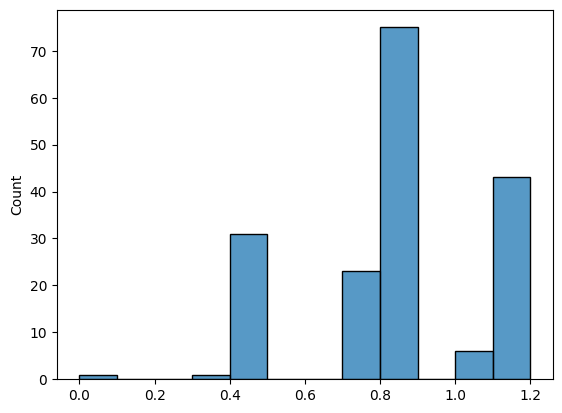

In [87]:
import seaborn as sns
all_scores = np.array(all_scores)
sns.histplot(all_scores, bins=12)

['device', 'mussel', 'diviner', 'freezer', 'trout', 'phone', 'robin', 'game', 'frog', 'machine', 'coral', 'scarf', 'Spider Plant', 'wandcore', 'rune', 'raccoon', 'bowl', 'backpack', 'oracle', 'Gingerbread'] ['robin', 'Gingerbread', 'Spider Plant']


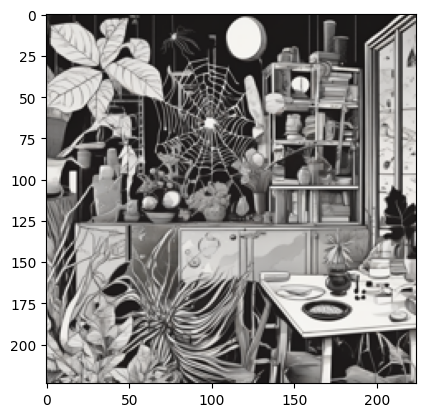

In [91]:
worst_idx = all_scores.argsort()
img, options, labels = ds_train[worst_idx[0]]
plt.imshow(img)
print(options, labels)